In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('state_crime.csv')

In [28]:
data

,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750
5,Colorado,340.9,3.2,89.3,12.9,21.4,84.6,76.86,10.7,34.3,9.91494,81.166667
6,Connecticut,300.5,3.0,88.6,9.4,25.0,79.1,84.83,11.4,34.4,7.97402,75.125000
7,Delaware,645.1,4.6,87.4,10.8,27.6,71.9,68.71,12.6,38.4,7.42068,115.196429
8,District of Columbia,1348.9,24.2,87.1,18.4,48.0,38.7,100.00,12.9,66.4,18.40000,53.527778
9,Florida,612.6,5.5,85.3,14.9,26.6,76.9,87.44,14.7,41.5,13.02856,94.246154


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    51 non-null     str    
 1   violent                  51 non-null     float64
 2   murder                   51 non-null     float64
 3   hs_grad                  51 non-null     float64
 4   poverty                  51 non-null     float64
 5   single                   51 non-null     float64
 6   white                    51 non-null     float64
 7   urban                    51 non-null     float64
 8   graduation_gap           51 non-null     float64
 9   social_stress_index      51 non-null     float64
 10  urban_stress_index       51 non-null     float64
 11  violent_to_murder_ratio  51 non-null     float64
dtypes: float64(11), str(1)
memory usage: 4.9 KB


In [5]:
# Imports + configuration

import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



def audit_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    # Quick EDA audit table: types, missingness, uniqueness.

    return (
        pd.DataFrame(
            {
                "dtype": df.dtypes.astype(str),
                "n_missing": df.isna().sum(),
                "missing_%": (df.isna().mean() * 100).round(2),
                "n_unique": df.nunique(dropna=False),
            }
        )
        .sort_values(["missing_%", "n_unique"], ascending=[False, True])
    )


def clip_quantiles(df: pd.DataFrame, cols: list[str], q_low: float = 0.01, q_high: float = 0.99) -> pd.DataFrame:
    # Winsorize/clip numeric columns to reduce extreme outlier influence on distances.

    out = df.copy()
    for c in cols:
        lo, hi = out[c].quantile([q_low, q_high])
        out[c] = out[c].clip(lo, hi)
    return out


def evaluate_clustering(X: np.ndarray, labels: np.ndarray) -> dict:
    # Compute a consistent metric bundle for clustering comparison.
    #
    # Why these metrics?
    # ------------------
    # 1) Silhouette (higher is better)
    #    - For each point i:
    #        a(i) = average distance from i to points in its own cluster
    #        b(i) = lowest average distance from i to points in any other cluster
    #      silhouette(i) = (b(i) - a(i)) / max(a(i), b(i))
    #    - Intuition: points should be close to their own cluster and far from others.
    #
    # 2) Davies–Bouldin index (lower is better)
    #    - For each cluster, compute how "wide" it is (scatter).
    #    - Compare that to distance between cluster centers.
    #    - Intuition: overlap/ambiguity between clusters should be low.
    #
    # 3) Calinski–Harabasz score (higher is better)
    #    - Ratio: (between-cluster dispersion) / (within-cluster dispersion)
    #    - Intuition: clusters should be far apart and internally tight.
    #
    # Important: these are *internal* metrics (no ground truth). Use them as guides,
    # then validate with interpretability.

    # If all labels are same, silhouette/CH are undefined
    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        return {
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    return {
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    }


In [6]:
raw = pd.read_csv("state_crime.csv")



In [7]:
raw.head()

,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750


In [8]:
raw.describe()

,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,411.482353,4.900000,86.878431,13.854902,25.186275,77.968627,60.670196,13.121569,39.041176,8.282031,74.401180
std,208.017447,3.646094,3.377769,3.110583,4.786565,13.553029,20.802432,3.377769,6.875760,3.078181,22.516655
min,119.900000,0.900000,79.900000,8.500000,17.900000,26.900000,17.380000,8.200000,28.000000,1.981320,38.822785
25%,263.350000,2.650000,84.050000,11.500000,22.100000,70.600000,46.565000,10.200000,34.500000,6.668860,60.224479
50%,366.400000,4.700000,87.400000,14.200000,25.500000,80.000000,59.170000,12.600000,38.400000,8.513750,72.138889
75%,507.400000,6.150000,89.800000,16.400000,27.300000,87.750000,78.415000,15.950000,42.400000,9.921030,86.482857
max,1348.900000,24.200000,91.800000,21.900000,48.000000,95.800000,100.000000,20.100000,66.400000,18.400000,150.619048


In [9]:
# Small cleanup driven by EDA:
# Some state names have trailing spaces (e.g., 'Kansas '), which can cause messy reporting.
raw["state"] = raw["state"].astype(str).str.strip()

display(raw.head())
print("Dataset shape:", raw.shape)

,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750


Dataset shape: (51, 12)


In [10]:
audit = audit_dataframe(raw)
display(audit)

print("Duplicate states:", raw["state"].duplicated().sum())

,dtype,n_missing,missing_%,n_unique
murder,float64,0,0.0,38
poverty,float64,0,0.0,40
single,float64,0,0.0,41
hs_grad,float64,0,0.0,42
graduation_gap,float64,0,0.0,42
social_stress_index,float64,0,0.0,46
white,float64,0,0.0,47
state,str,0,0.0,51
violent,float64,0,0.0,51
urban,float64,0,0.0,51


Duplicate states: 0


In [11]:
# Small cleanup driven by EDA:
# Some state names have trailing spaces (e.g., 'Kansas '), which can cause messy reporting.
raw["state"] = raw["state"].astype(str).str.strip()

display(raw.head())
print("Dataset shape:", raw.shape)

,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750


Dataset shape: (51, 12)


In [12]:
audit = audit_dataframe(raw)
display(audit)

print("Duplicate states:", raw["state"].duplicated().sum())

,dtype,n_missing,missing_%,n_unique
murder,float64,0,0.0,38
poverty,float64,0,0.0,40
single,float64,0,0.0,41
hs_grad,float64,0,0.0,42
graduation_gap,float64,0,0.0,42
social_stress_index,float64,0,0.0,46
white,float64,0,0.0,47
state,str,0,0.0,51
violent,float64,0,0.0,51
urban,float64,0,0.0,51


Duplicate states: 0


,count,mean,std,min,25%,50%,75%,max
violent,51.0,411.482353,208.017447,119.900000,263.350000,366.400000,507.400000,1348.900000
murder,51.0,4.900000,3.646094,0.900000,2.650000,4.700000,6.150000,24.200000
hs_grad,51.0,86.878431,3.377769,79.900000,84.050000,87.400000,89.800000,91.800000
poverty,51.0,13.854902,3.110583,8.500000,11.500000,14.200000,16.400000,21.900000
single,51.0,25.186275,4.786565,17.900000,22.100000,25.500000,27.300000,48.000000
white,51.0,77.968627,13.553029,26.900000,70.600000,80.000000,87.750000,95.800000
urban,51.0,60.670196,20.802432,17.380000,46.565000,59.170000,78.415000,100.000000
graduation_gap,51.0,13.121569,3.377769,8.200000,10.200000,12.600000,15.950000,20.100000
social_stress_index,51.0,39.041176,6.875760,28.000000,34.500000,38.400000,42.400000,66.400000
urban_stress_index,51.0,8.282031,3.078181,1.981320,6.668860,8.513750,9.921030,18.400000


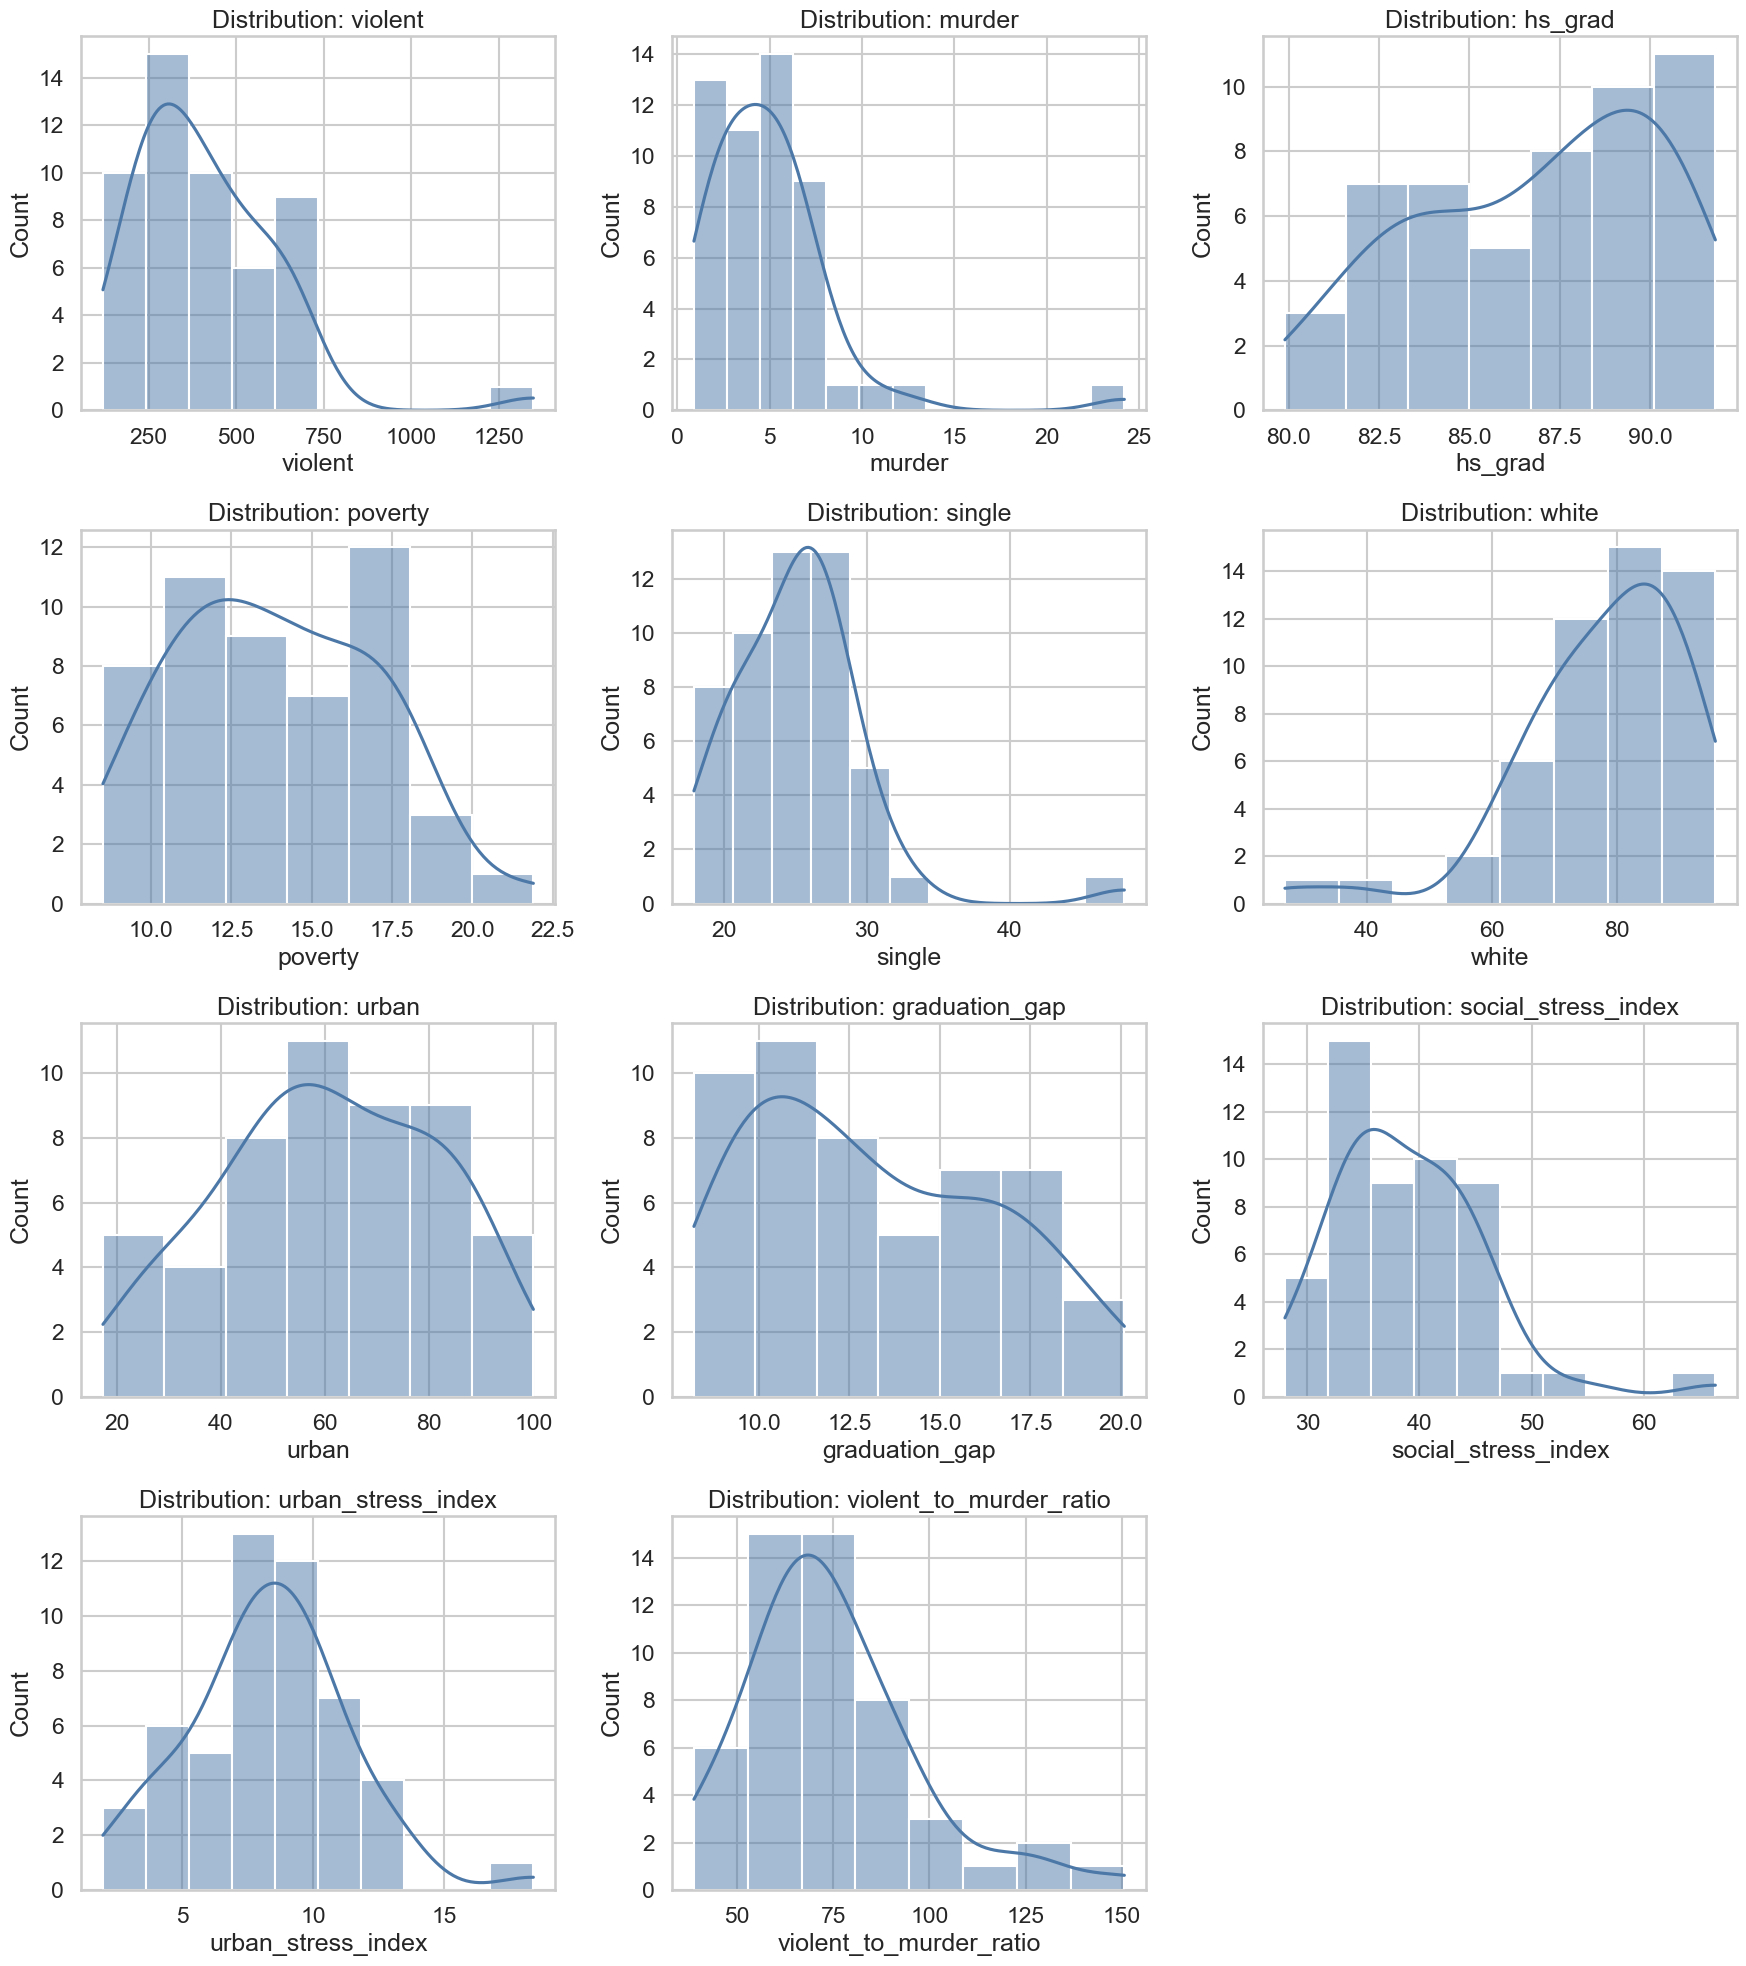

In [13]:
# Numeric columns (excluding the ID-like 'state')
num_cols = raw.columns.drop("state").tolist()

display(raw[num_cols].describe().T)

# Histograms
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    sns.histplot(raw[c], kde=True, ax=axes[i], color="#4C78A8")
    axes[i].set_title(f"Distribution: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

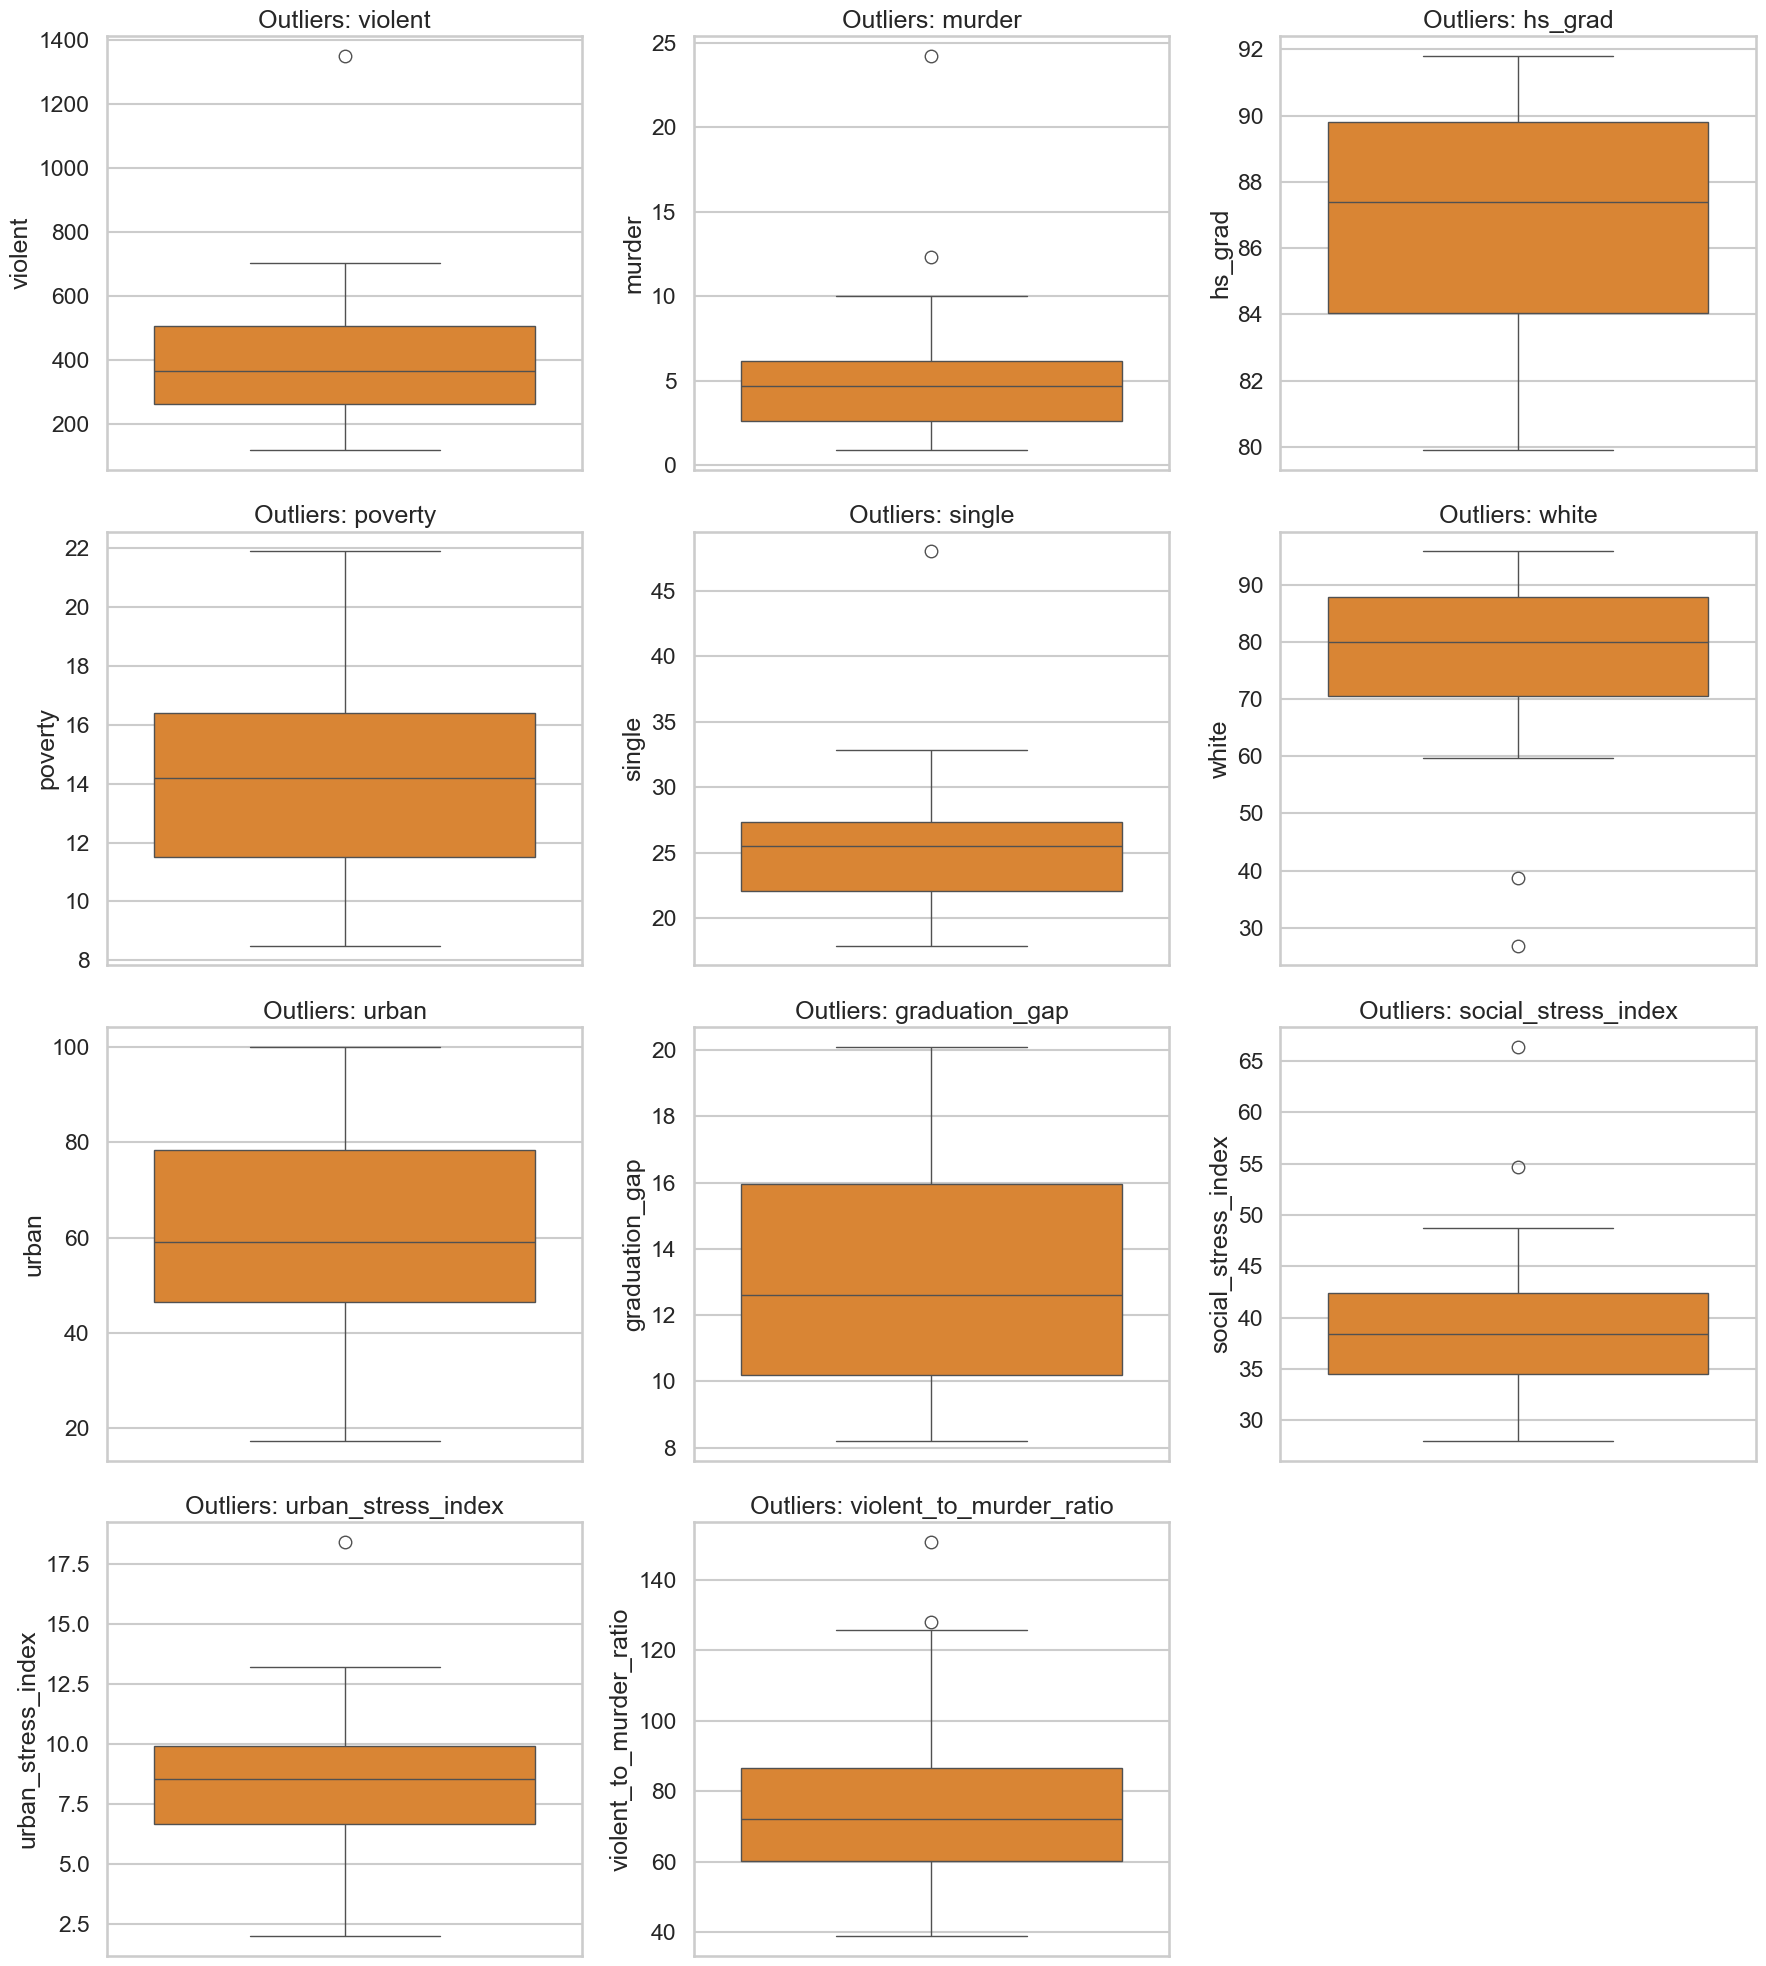

In [14]:
# Boxplots to visualize outliers
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    sns.boxplot(y=raw[c], ax=axes[i], color="#F58518")
    axes[i].set_title(f"Outliers: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# 1) Scale + shape summary

scale_shape = (
    raw[num_cols]
    .agg(["min", "max", "mean", "std", "skew"])
    .T
)
scale_shape["range"] = scale_shape["max"] - scale_shape["min"]
scale_shape = scale_shape.sort_values("range", ascending=False)

display(scale_shape.round(3))

# 2) Outlier counts using a classic boxplot rule (1.5 * IQR)
out_rows = []
for c in num_cols:
    q1, q3 = raw[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    n_out = int(((raw[c] < lo) | (raw[c] > hi)).sum())
    out_rows.append({"feature": c, "n_outliers_(1.5IQR)": n_out, "lo": lo, "hi": hi})

outlier_summary = pd.DataFrame(out_rows).sort_values("n_outliers_(1.5IQR)", ascending=False)
display(outlier_summary)

# 3) Concrete examples: which states are at extremes for key features?
key_uni = ["violent", "murder", "poverty", "hs_grad", "violent_to_murder_ratio", "social_stress_index"]
for c in key_uni:
    display(
        raw[["state", c]]
        .sort_values(c, ascending=False)
        .head(5)
        .rename(columns={c: f"{c} (top 5)"})
    )

,min,max,mean,std,skew,range
violent,119.900,1348.900,411.482,208.017,1.905,1229.000
violent_to_murder_ratio,38.823,150.619,74.401,22.517,1.157,111.796
urban,17.380,100.000,60.670,20.802,-0.147,82.620
white,26.900,95.800,77.969,13.553,-1.521,68.900
social_stress_index,28.000,66.400,39.041,6.876,1.355,38.400
single,17.900,48.000,25.186,4.787,2.061,30.100
murder,0.900,24.200,4.900,3.646,3.166,23.300
urban_stress_index,1.981,18.400,8.282,3.078,0.413,16.419
poverty,8.500,21.900,13.855,3.111,0.259,13.400
hs_grad,79.900,91.800,86.878,3.378,-0.398,11.900


,feature,n_outliers_(1.5IQR),lo,hi
1,murder,2,-2.600000,11.400000
8,social_stress_index,2,22.650000,54.250000
5,white,2,44.875000,113.475000
10,violent_to_murder_ratio,2,20.836912,125.870424
0,violent,1,-102.725000,873.475000
9,urban_stress_index,1,1.790605,14.799285
4,single,1,14.300000,35.100000
2,hs_grad,0,75.425000,98.425000
3,poverty,0,4.150000,23.750000
6,urban,0,-1.210000,126.190000


,state,violent (top 5)
8,District of Columbia,1348.9
28,Nevada,704.6
40,South Carolina,675.1
42,Tennessee,666.0
31,New Mexico,652.8


,state,murder (top 5)
8,District of Columbia,24.2
18,Louisiana,12.3
31,New Mexico,10.0
13,Illinois,8.4
20,Maryland,7.7


,state,poverty (top 5)
24,Mississippi,21.9
3,Arkansas,18.8
17,Kentucky,18.6
8,District of Columbia,18.4
31,New Mexico,18.0


,state,hs_grad (top 5)
50,Wyoming,91.8
23,Minnesota,91.5
1,Alaska,91.4
29,New Hampshire,91.3
45,Vermont,91.0


,state,violent_to_murder_ratio (top 5)
1,Alaska,150.619048
15,Iowa,128.043478
21,Massachusetts,125.837838
7,Delaware,115.196429
28,Nevada,102.115942


,state,social_stress_index (top 5)
8,District of Columbia,66.4
24,Mississippi,54.7
18,Louisiana,48.7
31,New Mexico,47.1
0,Alabama,46.5


In [16]:
# 4) Convert univariate summaries into a compact findings table

top_range = scale_shape.head(3).index.tolist()
top_skew = scale_shape.sort_values("skew", key=lambda s: s.abs(), ascending=False).head(3).index.tolist()
top_outliers = outlier_summary.head(3)["feature"].tolist()

univariate_findings = pd.DataFrame(
    [
        {
            "finding": "Strong scale differences across features",
            "evidence": f"Largest ranges: {top_range}",
            "why_it_matters": "Distance-based clustering is dominated by large-scale features.",
            "preprocessing_action": "Use StandardScaler (or RobustScaler) before KMeans/Agglomerative.",
        },
        {
            "finding": "Some features are highly skewed / heavy-tailed",
            "evidence": f"Most skewed (|skew|): {top_skew}",
            "why_it_matters": "Heavy tails make cluster boundaries sensitive to extreme points.",
            "preprocessing_action": "Consider clipping/winsorization or RobustScaler; re-check metrics.",
        },
        {
            "finding": "Outliers exist in multiple features",
            "evidence": f"Most IQR-outliers: {top_outliers}",
            "why_it_matters": "A few states can pull centroids and distort distances.",
            "preprocessing_action": "Test a mild quantile clip (1%–99%) and compare scorecard.",
        },
    ]
)

display(univariate_findings)

,finding,evidence,why_it_matters,preprocessing_action
0,Strong scale differences across features,"Largest ranges: ['violent', 'violent_to_murder...",Distance-based clustering is dominated by larg...,Use StandardScaler (or RobustScaler) before KM...
1,Some features are highly skewed / heavy-tailed,"Most skewed (|skew|): ['murder', 'single', 'vi...",Heavy tails make cluster boundaries sensitive ...,Consider clipping/winsorization or RobustScale...
2,Outliers exist in multiple features,"Most IQR-outliers: ['murder', 'social_stress_i...",A few states can pull centroids and distort di...,Test a mild quantile clip (1%–99%) and compare...


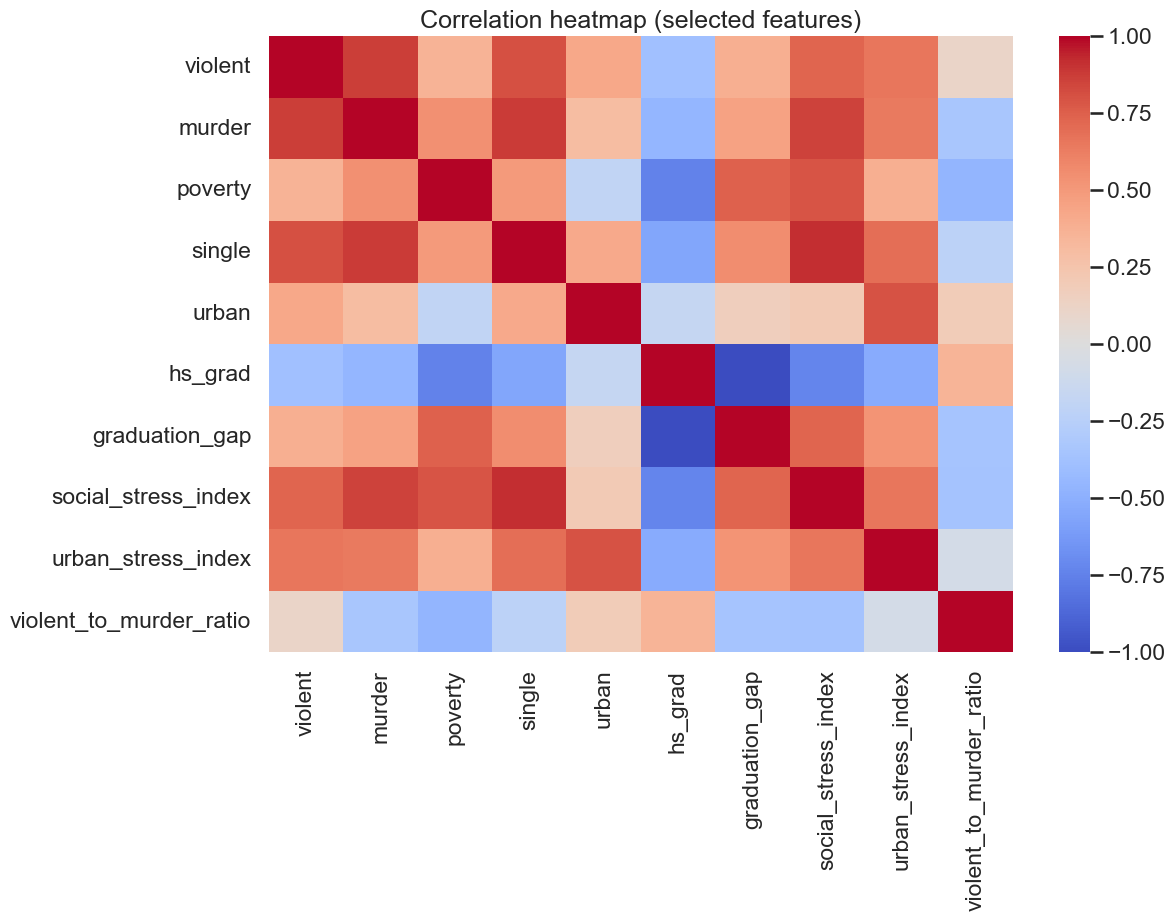

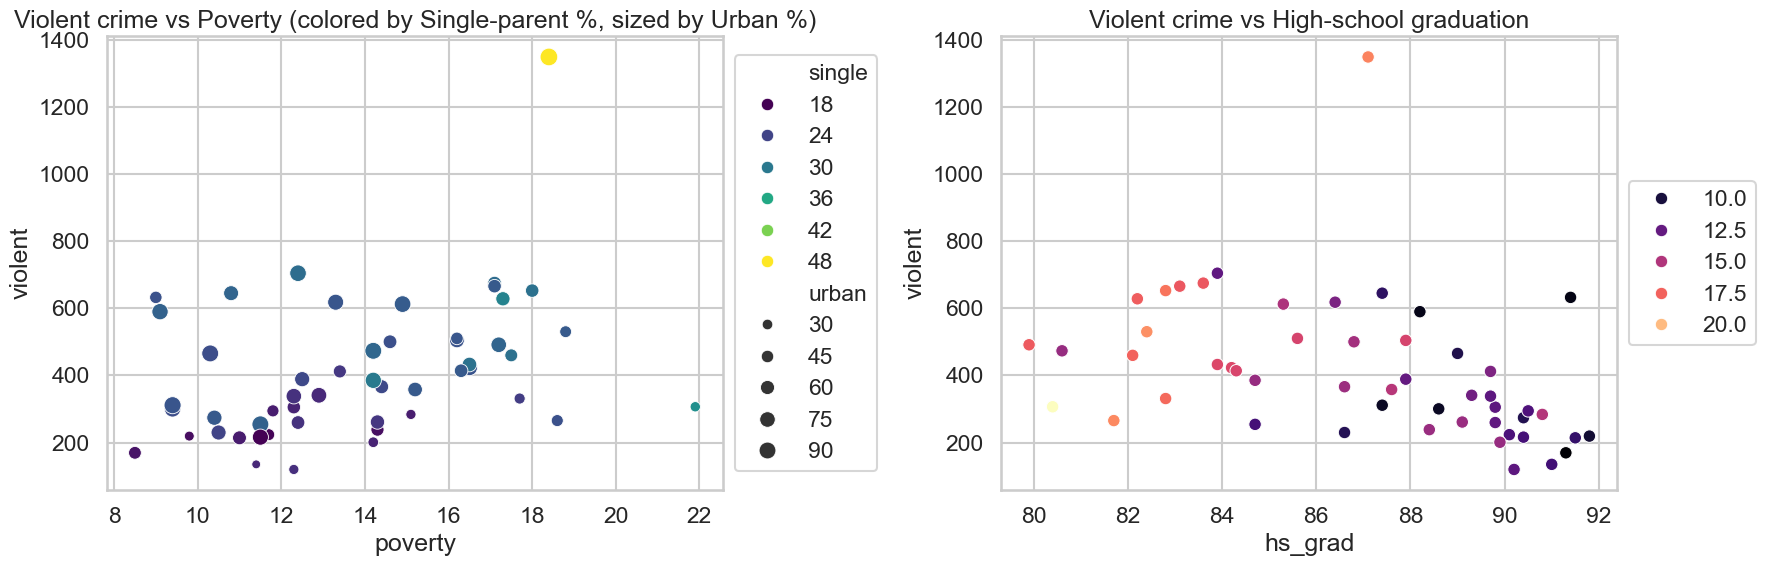

In [17]:
selected = [
    "violent",
    "murder",
    "poverty",
    "single",
    "urban",
    "hs_grad",
    "graduation_gap",
    "social_stress_index",
    "urban_stress_index",
    "violent_to_murder_ratio",
]

plt.figure(figsize=(12, 8))
sns.heatmap(raw[selected].corr(numeric_only=True), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap (selected features)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=raw, x="poverty", y="violent", hue="single", size="urban", palette="viridis", ax=axes[0])
axes[0].set_title("Violent crime vs Poverty (colored by Single-parent %, sized by Urban %)")
axes[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.scatterplot(data=raw, x="hs_grad", y="violent", hue="poverty", palette="magma", ax=axes[1])
axes[1].set_title("Violent crime vs High-school graduation")
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

Explained variance ratio (PC1, PC2): [0.564 0.192]


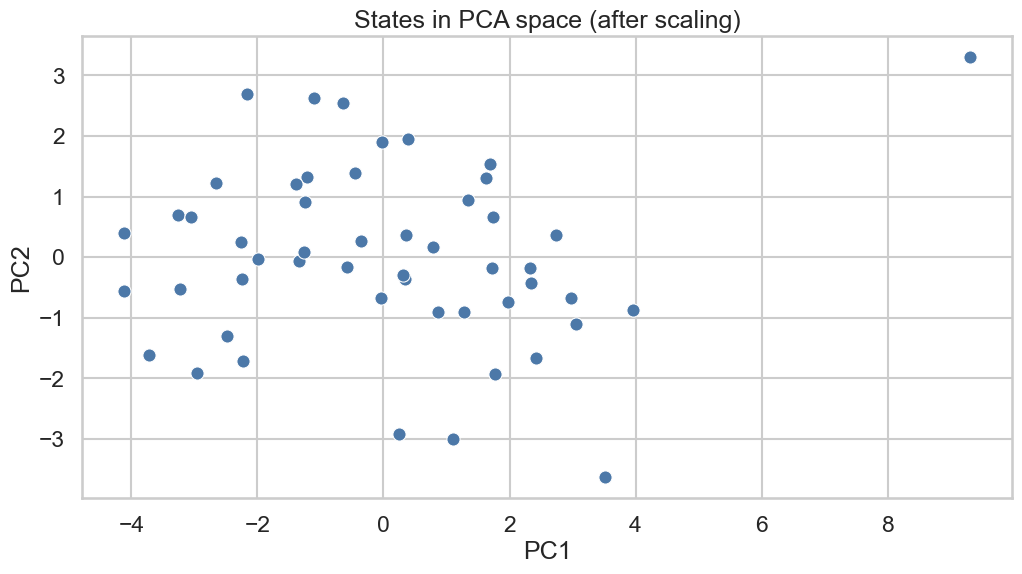

,PC1_loading,PC2_loading
social_stress_index,0.384563,-0.102184
single,0.370507,0.123580
murder,0.349682,0.067199
urban_stress_index,0.319675,0.248769
violent,0.316899,0.264435
graduation_gap,0.311930,-0.282792
hs_grad,-0.311930,0.282792
poverty,0.279917,-0.416037
white,-0.269614,-0.262808
urban,0.168803,0.495204


In [18]:
feature_cols = raw.columns.drop("state").tolist()
X = raw[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["state"] = raw["state"]

print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=90, color="#4C78A8")
plt.title("States in PCA space (after scaling)")
plt.show()

# PCA loadings: rough "feature importance" for each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1_loading", "PC2_loading"],
).sort_values("PC1_loading", key=lambda s: s.abs(), ascending=False)

display(loadings.head(10))

In [19]:
def run_kmeans_grid(X_in: np.ndarray, k_values: list[int], n_init: int = 50) -> pd.DataFrame:
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=n_init)
        labels = model.fit_predict(X_in)
        metrics = evaluate_clustering(X_in, labels)
        rows.append(
            {
                "algo": "KMeans",
                "k": k,
                "params": f"n_init={n_init}",
                "inertia": model.inertia_,
                **metrics,
            }
        )
    return pd.DataFrame(rows)


def run_agglomerative_grid(X_in: np.ndarray, k_values: list[int], linkages: list[str]) -> pd.DataFrame:
    rows = []
    for linkage in linkages:
        for k in k_values:
            # sklearn API changed across versions: `metric` vs `affinity`.
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric="euclidean")
            except TypeError:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage, affinity="euclidean")

            labels = model.fit_predict(X_in)
            metrics = evaluate_clustering(X_in, labels)
            rows.append(
                {
                    "algo": "Agglomerative",
                    "k": k,
                    "params": f"linkage={linkage}",
                    "inertia": np.nan,
                    **metrics,
                }
            )
    return pd.DataFrame(rows)

,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
1,KMeans,3,n_init=50,377373.573940,3,0.566600,0.414619,117.568370
0,KMeans,2,n_init=50,950118.078360,2,0.563274,0.600877,65.800815
2,KMeans,4,n_init=50,188108.600184,4,0.526369,0.440220,169.726800
3,KMeans,5,n_init=50,121657.504189,5,0.445338,0.574897,198.919222
4,KMeans,6,n_init=50,93250.497427,6,0.407933,0.619735,205.841327
5,KMeans,7,n_init=50,76171.521684,7,0.403382,0.671467,206.973130
6,KMeans,8,n_init=50,67077.770143,8,0.347270,0.772413,197.710690


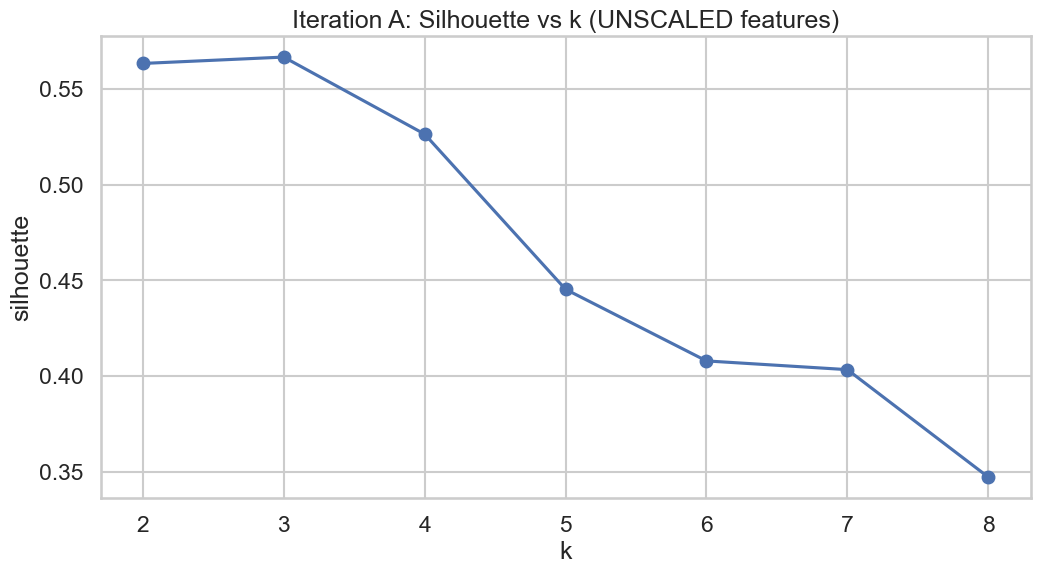

In [20]:
k_values = list(range(2, 9))

X_raw = raw[feature_cols].to_numpy(dtype=float)

baseline_raw = run_kmeans_grid(X_raw, k_values=k_values, n_init=50)
display(baseline_raw.sort_values(["silhouette"], ascending=False).head(10))

plt.plot(baseline_raw["k"], baseline_raw["silhouette"], marker="o")
plt.title("Iteration A: Silhouette vs k (UNSCALED features)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()

,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
1,KMeans,3,n_init=100,262.290402,3,0.330981,0.816642,27.332416
0,KMeans,2,n_init=100,352.918882,2,0.326738,1.138397,28.890420
2,KMeans,4,n_init=100,205.856748,4,0.258577,0.966729,27.028072
3,KMeans,5,n_init=100,176.615591,5,0.254670,1.008324,25.028485
6,KMeans,8,n_init=100,120.150544,8,0.235072,0.910372,22.539018
4,KMeans,6,n_init=100,152.473752,6,0.228959,1.057360,24.113896
5,KMeans,7,n_init=100,132.549571,7,0.226829,1.021433,23.704112


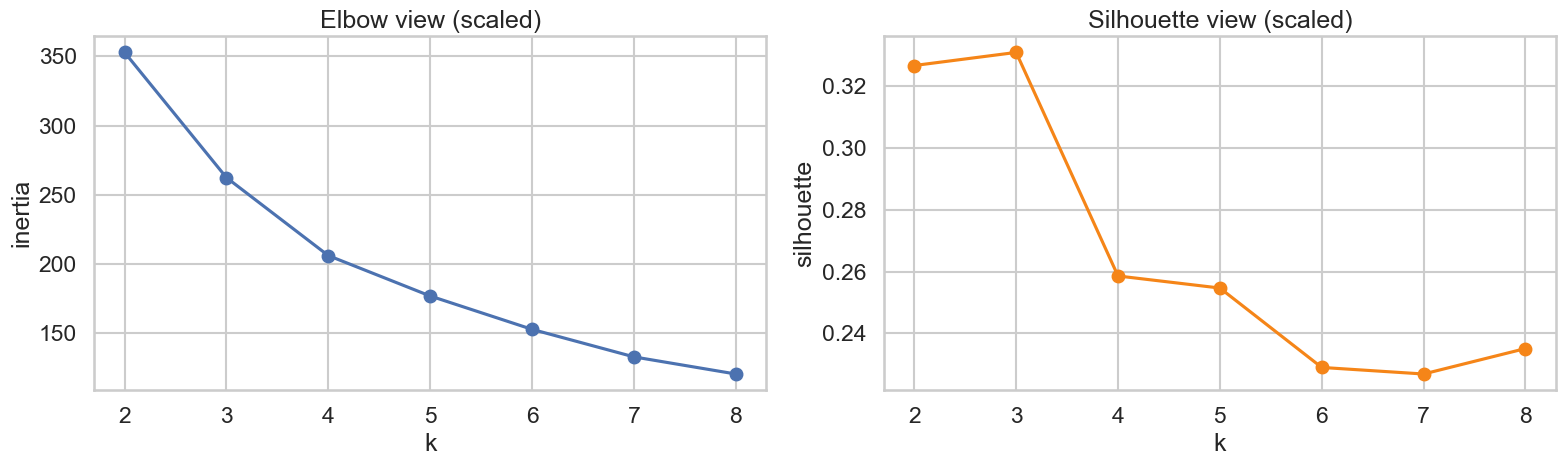

Best k by silhouette (Iteration B): 3


In [21]:
X_std = StandardScaler().fit_transform(X_raw)

baseline_std = run_kmeans_grid(X_std, k_values=k_values, n_init=100)
display(baseline_std.sort_values(["silhouette"], ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(baseline_std["k"], baseline_std["inertia"], marker="o")
axes[0].set_title("Elbow view (scaled)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")

axes[1].plot(baseline_std["k"], baseline_std["silhouette"], marker="o", color="#F58518")
axes[1].set_title("Silhouette view (scaled)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

best_k_std = int(baseline_std.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Best k by silhouette (Iteration B):", best_k_std)


,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,2,n_init=200,338.023242,2,0.332725,1.115697,32.322810
2,KMeans,4,n_init=200,221.441130,4,0.254786,1.004380,24.023340
1,KMeans,3,n_init=200,277.085305,3,0.245060,1.306925,24.591534
3,KMeans,5,n_init=200,190.558674,5,0.234467,1.193698,22.355714
4,KMeans,6,n_init=200,164.202066,6,0.224690,1.117453,21.748700
5,KMeans,7,n_init=200,143.368073,7,0.223937,1.034920,21.362037
6,KMeans,8,n_init=200,129.023095,8,0.221915,1.072812,20.566647


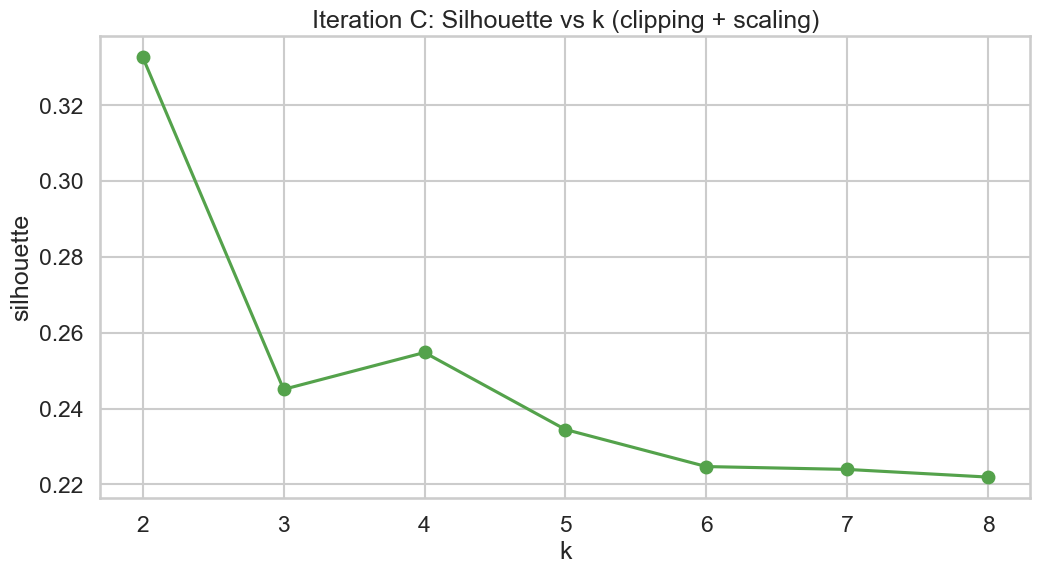

In [22]:
raw_clipped = clip_quantiles(raw, cols=feature_cols, q_low=0.01, q_high=0.99)
X_clip = raw_clipped[feature_cols].to_numpy(dtype=float)
X_clip_std = StandardScaler().fit_transform(X_clip)

clip_std = run_kmeans_grid(X_clip_std, k_values=k_values, n_init=200)
display(clip_std.sort_values(["silhouette"], ascending=False).head(10))

plt.plot(clip_std["k"], clip_std["silhouette"], marker="o", color="#54A24B")
plt.title("Iteration C: Silhouette vs k (clipping + scaling)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()


In [23]:
agg = run_agglomerative_grid(X_std, k_values=k_values, linkages=["ward", "complete", "average"])

display(agg.sort_values("silhouette", ascending=False).head(10))

,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
7,Agglomerative,2,linkage=complete,NaN,2,0.627541,0.256305,12.940718
14,Agglomerative,2,linkage=average,NaN,2,0.627541,0.256305,12.940718
8,Agglomerative,3,linkage=complete,NaN,3,0.315010,0.852584,25.033892
0,Agglomerative,2,linkage=ward,NaN,2,0.312897,1.171721,26.956078
1,Agglomerative,3,linkage=ward,NaN,3,0.306128,0.842088,24.917963
16,Agglomerative,4,linkage=average,NaN,4,0.292665,0.722481,18.801609
15,Agglomerative,3,linkage=average,NaN,3,0.264818,0.479509,7.866373
10,Agglomerative,5,linkage=complete,NaN,5,0.258019,0.953131,20.135593
17,Agglomerative,5,linkage=average,NaN,5,0.252612,0.667507,15.475515
9,Agglomerative,4,linkage=complete,NaN,4,0.247776,0.924271,20.138969


In [24]:
def add_iteration_tag(df: pd.DataFrame, iteration: str, preprocessing: str) -> pd.DataFrame:
    out = df.copy()
    out.insert(0, "iteration", iteration)
    out.insert(1, "preprocessing", preprocessing)
    return out


scorecard = pd.concat(
    [
        add_iteration_tag(baseline_raw, "A", "raw/unscaled"),
        add_iteration_tag(baseline_std, "B", "StandardScaler"),
        add_iteration_tag(clip_std, "C", "clip(1%-99%)+StandardScaler"),
        add_iteration_tag(agg, "D", "StandardScaler"),
    ],
    ignore_index=True,
)

# A convenient single sort order:
scorecard_sorted = scorecard.sort_values(
    ["silhouette", "davies_bouldin"], ascending=[False, True]
)

display(scorecard_sorted.head(20).round(4))

best_row = scorecard_sorted.iloc[0]
print("Best configuration by (silhouette desc, DB asc):")
display(best_row)

,iteration,preprocessing,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
28,D,StandardScaler,Agglomerative,2,linkage=complete,NaN,2,0.6275,0.2563,12.9407
35,D,StandardScaler,Agglomerative,2,linkage=average,NaN,2,0.6275,0.2563,12.9407
1,A,raw/unscaled,KMeans,3,n_init=50,377373.5739,3,0.5666,0.4146,117.5684
0,A,raw/unscaled,KMeans,2,n_init=50,950118.0784,2,0.5633,0.6009,65.8008
2,A,raw/unscaled,KMeans,4,n_init=50,188108.6002,4,0.5264,0.4402,169.7268
3,A,raw/unscaled,KMeans,5,n_init=50,121657.5042,5,0.4453,0.5749,198.9192
4,A,raw/unscaled,KMeans,6,n_init=50,93250.4974,6,0.4079,0.6197,205.8413
5,A,raw/unscaled,KMeans,7,n_init=50,76171.5217,7,0.4034,0.6715,206.9731
6,A,raw/unscaled,KMeans,8,n_init=50,67077.7701,8,0.3473,0.7724,197.7107
14,C,clip(1%-99%)+StandardScaler,KMeans,2,n_init=200,338.0232,2,0.3327,1.1157,32.3228


Best configuration by (silhouette desc, DB asc):


iteration                           D
preprocessing          StandardScaler
algo                    Agglomerative
k                                   2
params               linkage=complete
inertia                           NaN
n_clusters                          2
silhouette                   0.627541
davies_bouldin               0.256305
calinski_harabasz           12.940718
Name: 28, dtype: object

In [25]:
# You can change this choice after inspecting the scorecard.
FINAL_ALGO = "KMeans"
FINAL_K = 3
FINAL_PREPROCESSING = "StandardScaler"  # {"StandardScaler", "clip"}

if FINAL_PREPROCESSING == "StandardScaler":
    X_final = X_std
elif FINAL_PREPROCESSING == "clip":
    X_final = X_clip_std
else:
    raise ValueError("Unknown preprocessing")

if FINAL_ALGO == "KMeans":
    final_model = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=200)
    final_labels = final_model.fit_predict(X_final)
elif FINAL_ALGO == "Agglomerative":
    try:
        final_model = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward", metric="euclidean")
    except TypeError:
        final_model = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward", affinity="euclidean")
    final_labels = final_model.fit_predict(X_final)
    final_labels = final_model.fit_predict(X_final)
else:
    raise ValueError("Unknown algorithm")

final_metrics = evaluate_clustering(X_final, final_labels)
print("Final metrics:", {k: round(v, 4) if isinstance(v, float) else v for k, v in final_metrics.items()})

df_labeled = raw.copy()
df_labeled["cluster"] = final_labels
display(df_labeled[["state", "cluster"]].head())

print("Cluster sizes:\n", df_labeled["cluster"].value_counts().sort_index())


Final metrics: {'n_clusters': 3, 'silhouette': 0.331, 'davies_bouldin': 0.8166, 'calinski_harabasz': 27.3324}


,state,cluster
0,Alabama,0
1,Alaska,1
2,Arizona,0
3,Arkansas,0
4,California,0


Cluster sizes:
 cluster
0    24
1    26
2     1
Name: count, dtype: int64


In [27]:
display(df_labeled[["state", "cluster"]])

,state,cluster
0,Alabama,0
1,Alaska,1
2,Arizona,0
3,Arkansas,0
4,California,0
5,Colorado,1
6,Connecticut,1
7,Delaware,1
8,District of Columbia,2
9,Florida,0
